Size of Training Data  torch.Size([79798, 1, 32])
Size of Training Labels torch.Size([79798, 1])
Epoch [1/10], Loss: 0.3993
Train Accuracy: 98.89%
Test Accuracy: 97.24%
Epoch [2/10], Loss: 0.1011
Train Accuracy: 99.39%
Test Accuracy: 98.48%
Epoch [3/10], Loss: 0.0064
Train Accuracy: 99.54%
Test Accuracy: 98.70%
Epoch [4/10], Loss: 0.0052
Train Accuracy: 99.66%
Test Accuracy: 98.89%
Epoch [5/10], Loss: 0.0026
Train Accuracy: 99.73%
Test Accuracy: 99.00%
Epoch [6/10], Loss: 0.0031
Train Accuracy: 99.74%
Test Accuracy: 98.93%
Epoch [7/10], Loss: 0.0017
Train Accuracy: 99.75%
Test Accuracy: 99.07%
Epoch [8/10], Loss: 0.0016
Train Accuracy: 99.75%
Test Accuracy: 99.13%
Epoch [9/10], Loss: 0.0020
Train Accuracy: 99.76%
Test Accuracy: 99.06%
Epoch [10/10], Loss: 0.0032
Train Accuracy: 99.76%
Test Accuracy: 99.15%


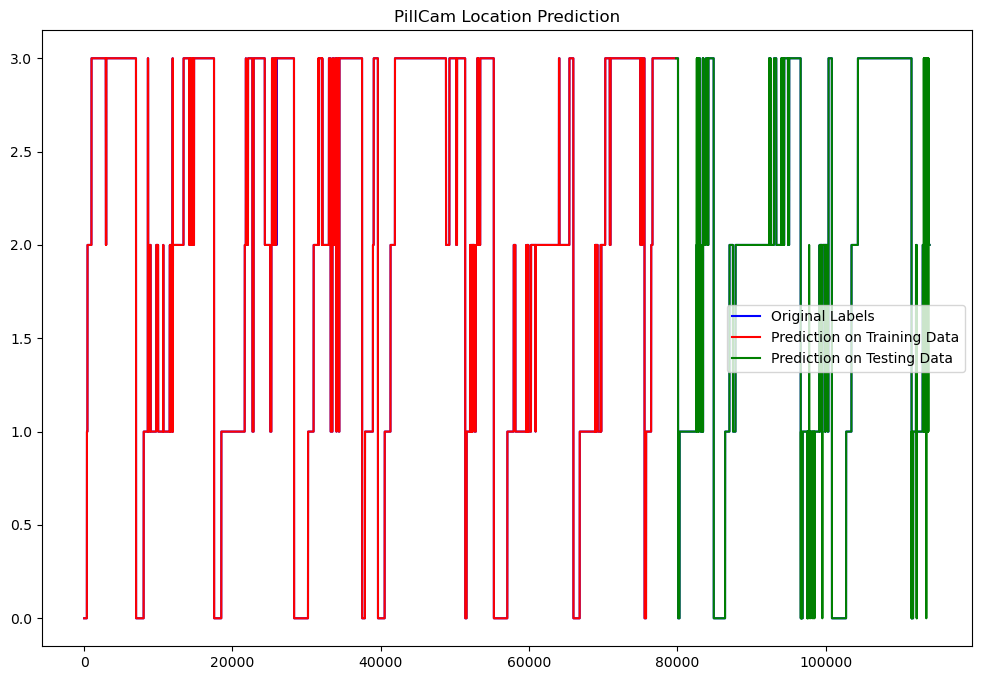

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import torch.utils.data as data
from matplotlib.pyplot import figure
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
import random

# Check if a GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lookback = 10 # no of prior outputs to use

# Define hyperparameters
input_size = (lookback+1)*2+lookback  # Number of features and prior outputs
hidden_size = 64  # Number of LSTM units
no_of_layers = 2  # Number of LSTM stacked layers
num_classes = 4  # Number of output classes        
dropout_prob = 0.3  # 0.2 Dropout probability
batch_size = 32
num_epochs = 10


# Define a function to inject noise into random segments of the data
def inject_noise_into_random_segments(data, num_segments, max_segment_length):
    """
    Inject random values from the same distribution as the channel.

    Args:
    - data (torch.Tensor): The input time series data with 32 features.
    - num_segments (int): Number of random segments to augment.
    - max_segment_length (int): Maximum length of each segment.    

    Returns:
    - noisy_data (torch.Tensor): The data with added noise in random segments and dimensions.
    """
    noisy_data = data.clone() # Make a copy of the data
    data_size = data.size(0)
    num_features = data.size(1)
    
    random_indices = [random.randint(0, data_size - max_segment_length) for _ in range(num_segments)]
    
    
    # no of channles to be made noisy
    no_of_channels = int(num_features/2)    
        
    #Create noise tensors
    noise_tensors = [torch.randn(max_segment_length) for _ in range(num_segments)]
    
    for i in range(num_segments):
        index = random_indices[i]
        #  Generate random dimensions to insert noise
        noise_dimensions = random.sample(range(num_features), no_of_channels)
        
    
        for j in range(len(noise_dimensions)):
            dim = noise_dimensions[j]
            # Extract the data for the selected dimension
            dim_data = data[:, dim]
            # Generate random values from the same distribution as the channel
            random_values = torch.from_numpy(np.random.choice(dim_data, size=data.shape[0]))
            # Replace the data in the chosen dimension with the random values
            noisy_data[index:index + max_segment_length, dim] = random_values[index:index + max_segment_length]
            
        
    
    return noisy_data



# Read data from a csv file
df = pd.read_csv(r'C:\Users\psh006\OneDrive - UiT Office 365\ML codes\AICE\data.csv')


X = df.iloc[:, [0,2]] # 0 corresponds to time and 2 corresponds to pred. probability 
# Calculate the difference between consecutive data points (time and pred. probability differences)
X_diff = X.diff()
# Fill the first NaN values by 0
X_diff = X_diff.fillna(0)
# Replace large X_diff values with zero as they indicate change from one patient to another
X_diff[np.abs(X_diff) >= 0.5] = 0
y = df.iloc[:, [1]] # Class label


# # Extract the first row (first dimension) as a 1D array
# time_diff = X_diff.iloc[:, 0]
# prob_diff = X_diff.iloc[:, 1]


# plt.figure(figsize=(10,6)) #plotting
# plt.plot(prob_diff, c='b', label='prob. difference') 
# plt.plot(time_diff, c='r',label ='time difference') 
# #plt.plot(y, label='Output') 
# plt.legend()
# plt.title('Data')


# Initialize the RobustScaler
scaler = RobustScaler()
# Fit the scaler on data and transform it
X_ss = scaler.fit_transform(X_diff.values)
y_mm = y.values




# train-test split for time series data
train_size = int(len(y_mm) * 0.70)
test_size = len(y_mm) - train_size
train_data, test_data = X_ss[:train_size], X_ss[train_size:]
train_labels, test_labels = y_mm[:train_size], y_mm[train_size:]



def create_dataset(data, labels, lookback):
    """Transform a series data into a prediction dataset
    
    Args:
        dataset: A numpy array of series where first dimension is the time
        and second is the prob. from classifier and thrid is prev ouputs
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(data)-lookback):
       
        # Extract for example 5 consecutive elements as features, slicing numpy array
        # it will start from 0,1,..4, lookback+1 selects the current feature as well
        feat = data[i:i+lookback+1,:]         
        prev_output = labels[i:i+lookback]
        # this will be the 6th element of the array  
        target = labels[i+lookback]       
        
        feat = np.reshape(feat,(feat.size))# make it 1 dimensional      
        prev_output = np.reshape(prev_output,(prev_output.size))# make it 1 dimensional
        
        # combine the previous outputs with rest of the feat
        features = np.concatenate((feat, prev_output), axis=0)
        features = np.reshape(features,(features.size))      
        X.append(features) # Using time, pred probabilities, and previous outputs as features
        y.append(target)   
       
   
    return torch.tensor(X), torch.tensor(y) # retuned as tensors
 

X_train, labels_train = create_dataset(train_data, train_labels, lookback=lookback)
X_test, labels_test = create_dataset(test_data, test_labels, lookback=lookback)


# Define parameters for augmentation
num_segments = 50
max_segment_length = 100

# Inject noise into random segments of the dataset
X_train_new = inject_noise_into_random_segments(X_train, num_segments, max_segment_length)

# for j in range(X_train.size(1)):
#     dimension_to_plot = j  # Change this to the desired dimension
#     # Extract the selected dimension as a 1D array
#     dimension_new = X_train_new[:, dimension_to_plot]
#     dimension_orig = X_train[:, dimension_to_plot]


#     # Plot the data
#     plt.figure(figsize=(8, 4))
#     plt.plot(dimension_new, c='b', label='New')
#     plt.plot(dimension_orig, c='r', label='Orig')

#     plt.grid(True)
#     plt.title((f'Dimension {j + 1}'))
#     plt.show()
    



## casting to float32 to avoid runtime errors
X_train = X_train.to(torch.float32)
labels_train = labels_train.to(torch.long)

X_test = X_test.to(torch.float32)
labels_test = labels_test.to(torch.long)

X_train = X_train.unsqueeze(1)
X_test = X_test.unsqueeze(1)



print('Size of Training Data ',X_train.shape)
print('Size of Training Labels',labels_train.shape)

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward pass through the LSTM
        out, _ = self.lstm(x, (h0, c0))
        # Get the output at the last time step
        out = out[:, -1, :]
        # Pass through the fully connected layer
        out = self.fc(out)
        return out

        


# Create an instance of the SimpleLSTM model
model = LSTMModel(input_size, hidden_size, no_of_layers, num_classes, dropout_prob)




# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Create a DataLoader for training and testing data

# train with sub set of training data
train_loader = DataLoader(TensorDataset(X_train, labels_train), shuffle=True, batch_size=batch_size)
test_loader =  DataLoader(TensorDataset(X_test, labels_test), shuffle=False, batch_size=batch_size)




for epoch in range(num_epochs):
    for in_batch, in_labels in train_loader:
        
        
        optimizer.zero_grad()  
      
        outputs = model(in_batch)
        in_labels = in_labels.squeeze()
        #print(in_batch.shape,in_labels.shape)
        
        loss = criterion(outputs, in_labels)
        loss.backward()
        optimizer.step()
        
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_correct = 0.0
        test_total = 0.0
        train_correct = 0.0
        train_total = 0.0
        
        
        # Accuracy for training data per epoch
        train_outputs = model(X_train)
        _, train_predicted = torch.max(train_outputs.data, 1)
        train_total = labels_train.size(0)
        labels_train = labels_train.squeeze()            
        train_correct = (train_predicted == labels_train).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        print(f'Train Accuracy: {train_accuracy:.2f}%')
        
        # for plot
        train_predicted = train_predicted.data.numpy() #numpy conversion
        # Reshape the array into (N,1)
        train_predicted = train_predicted.reshape(-1, 1)
        train_plot = np.ones_like(y) * np.nan # defining train plot
        train_plot[lookback:train_size] = train_predicted 
        
        
        # Accuracy for testing data per epoch
        for test_inputs, test_labels in test_loader:

            test_outputs = model(test_inputs)
            _, test_predicted = torch.max(test_outputs.data, 1)
            test_total += test_labels.size(0)
            test_labels = test_labels.squeeze()            
            test_correct += (test_predicted == test_labels).sum().item()
        
        
        test_accuracy = 100 * test_correct / test_total
        print(f'Test Accuracy: {test_accuracy:.2f}%')
        
        
        # For plot
        test_out = model(X_test)
        _, test_pred = torch.max(test_out.data, 1)       
        test_pred = test_pred.data.numpy() #numpy conversion
        # Reshape the array into (N,1)
        test_pred = test_pred.reshape(-1, 1)
        # shift test predictions for plotting
        test_plot = np.ones_like(y) * np.nan  # defining test plot
        test_plot[train_size+lookback:len(y)] = test_pred
        
# plot
figure(figsize=(12, 8), dpi=100)
plt.plot(y, c= 'b',label='Original Labels')
plt.plot(train_plot, c='r',label='Prediction on Training Data')
plt.plot(test_plot, c='g',label='Prediction on Testing Data')
plt.title('PillCam Location Prediction')
plt.legend()
plt.show()
    
    
